In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("credit_card_customers.csv")

print(df.shape)
df.head()

(8000, 7)


,age,income,transactions,credit_limit,avg_spent,payment_delay,churn
0,56,147595,33,16378,2489,28,1
1,69,31549,78,11864,9220,22,0
2,46,91216,17,19803,3104,10,1
3,32,45739,57,5279,2907,15,0
4,60,41209,83,18057,563,16,0


In [3]:
# remove duplicates
df.drop_duplicates(inplace=True)

# fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

In [4]:
df.describe()

,age,income,transactions,credit_limit,avg_spent,payment_delay,churn
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,43.625500,85190.577375,49.528500,10667.930750,5226.565000,14.755375,0.507875
std,14.902785,37677.570895,28.434961,5485.095705,2727.118719,8.695990,0.499969
min,18.000000,20002.000000,1.000000,1003.000000,500.000000,0.000000,0.000000
25%,31.000000,52349.750000,25.000000,5865.500000,2904.000000,7.000000,0.000000
50%,43.000000,85621.500000,49.000000,10860.500000,5219.000000,15.000000,1.000000
75%,56.000000,117966.750000,74.000000,15383.500000,7580.250000,22.000000,1.000000
max,69.000000,149999.000000,99.000000,19997.000000,9999.000000,29.000000,1.000000


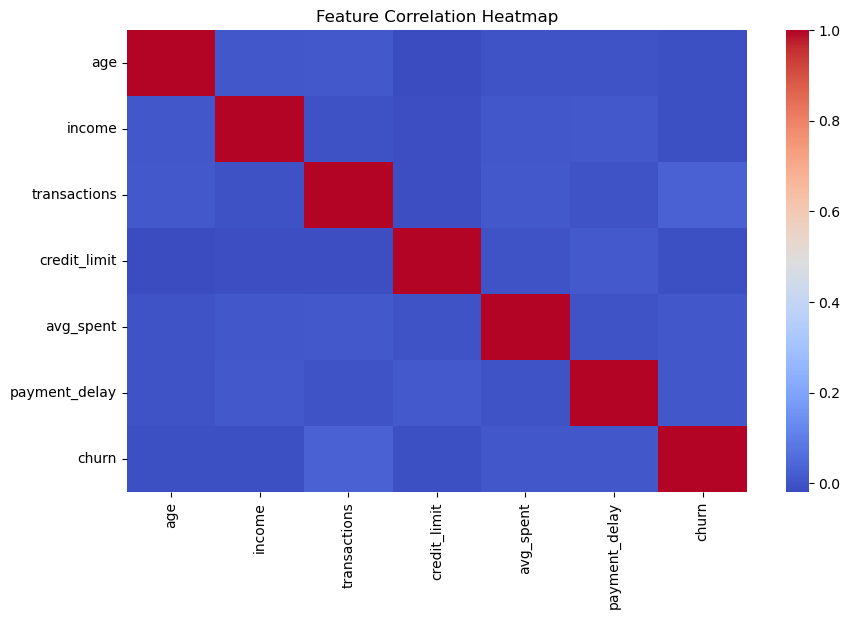

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

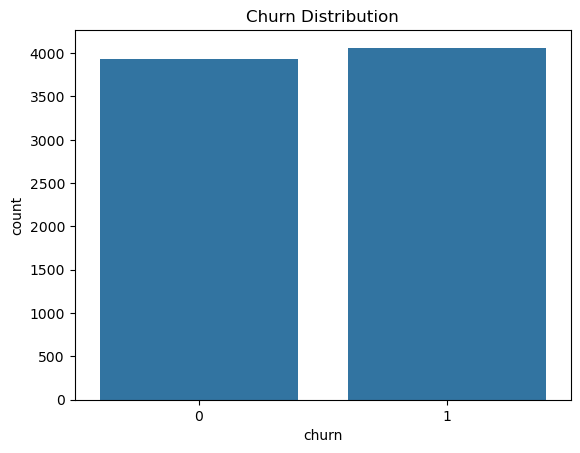

In [6]:
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [7]:
X_raw = df.drop("churn", axis=1)
y = df["churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [8]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

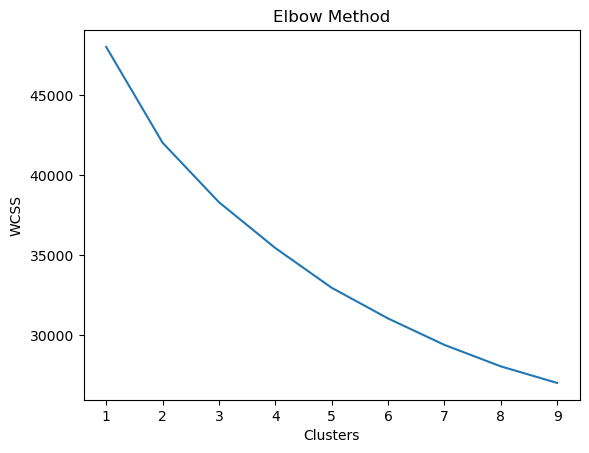

In [9]:
plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df.head()

,age,income,transactions,credit_limit,avg_spent,payment_delay,churn,Cluster
0,56,147595,33,16378,2489,28,1,1
1,69,31549,78,11864,9220,22,0,0
2,46,91216,17,19803,3104,10,1,1
3,32,45739,57,5279,2907,15,0,2
4,60,41209,83,18057,563,16,0,1


In [11]:
X = df.drop(["churn", "Cluster"], axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.508125
              precision    recall  f1-score   support

           0       0.49      0.49      0.49       764
           1       0.53      0.52      0.53       836

    accuracy                           0.51      1600
   macro avg       0.51      0.51      0.51      1600
weighted avg       0.51      0.51      0.51      1600



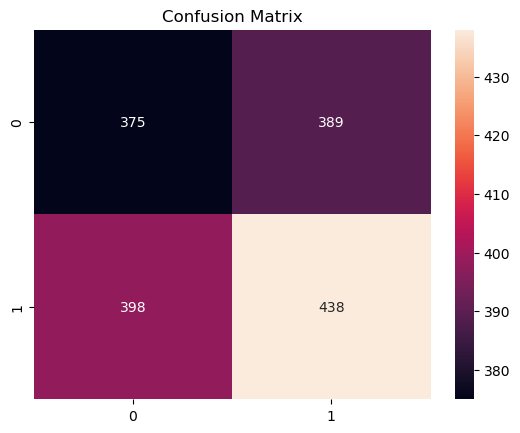

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [14]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
3,credit_limit,0.193708
1,income,0.189768
4,avg_spent,0.188614
2,transactions,0.155118
0,age,0.144004
5,payment_delay,0.128789


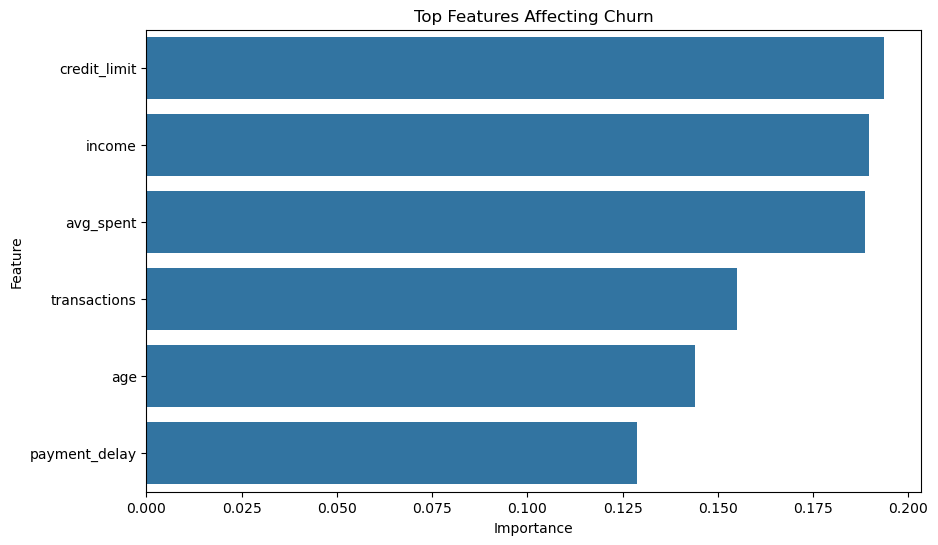

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10))
plt.title("Top Features Affecting Churn")
plt.show()

# 🧠 FINAL BUSINESS INSIGHTS

## 📊 Customer Segments:
- High-value customers → loyalty rewards
- Low engagement users → reactivation campaigns
- High-risk customers → churn prevention offers
- Stable users → cross-sell opportunities

## 🚨 Key Churn Drivers:
- Payment delays
- Low transaction frequency
- Low credit usage

## 💡 Business Strategy:
- Retain high-value customers
- Target risky users with offers
- Improve engagement via personalization